<a href="https://colab.research.google.com/github/smaran19/Employee-Attrition-Analysis-Prediction/blob/main/Employee_Attrition_Analysis_%26_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv("/content/drive/MyDrive/HR Data.xlsx - HR data.csv")

In [8]:
# Shape of data
print("Rows & Columns:", df.shape)

# Column names
print("\nColumn Names:\n", df.columns.tolist())

# First 5 records
df.head()


Rows & Columns: (1470, 39)

Column Names:
 ['Attrition', 'Business Travel', 'CF_age band', 'CF_attrition label', 'Department', 'Education Field', 'emp no', 'Employee Number', 'Gender', 'Job Role', 'Marital Status', 'Over Time', 'Over18', 'Training Times Last Year', 'Age', 'CF_current Employee', 'Daily Rate', 'Distance From Home', 'Education', 'Employee Count', 'Environment Satisfaction', 'Hourly Rate', 'Job Involvement', 'Job Level', 'Job Satisfaction', 'Monthly Income', 'Monthly Rate', 'Num Companies Worked', 'Percent Salary Hike', 'Performance Rating', 'Relationship Satisfaction', 'Standard Hours', 'Stock Option Level', 'Total Working Years', 'Work Life Balance', 'Years At Company', 'Years In Current Role', 'Years Since Last Promotion', 'Years With Curr Manager']


,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Employee Number,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,1,Female,Sales Executive,...,3,1,80,0,8,1,6,4,0,5
1,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,2,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7
2,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,4,Male,Laboratory Technician,...,3,2,80,0,7,3,0,0,0,0
3,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,5,Female,Research Scientist,...,3,3,80,0,8,3,8,7,3,0
4,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,7,Male,Laboratory Technician,...,3,4,80,1,6,3,2,2,2,2


In [9]:
# Missing values count
missing = df.isnull().sum()

# Missing values percentage
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df[missing_df['Missing Count'] > 0]


,Missing Count,Missing %


In [10]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [11]:
df = df.drop_duplicates()
print("Duplicates removed. New shape:", df.shape)


Duplicates removed. New shape: (1470, 39)


In [12]:
# Categorical columns check
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col} -> {df[col].nunique()} unique values")



Attrition -> 2 unique values

Business Travel -> 3 unique values

CF_age band -> 5 unique values

CF_attrition label -> 2 unique values

Department -> 3 unique values

Education Field -> 6 unique values

emp no -> 1470 unique values

Gender -> 2 unique values

Job Role -> 9 unique values

Marital Status -> 3 unique values

Over Time -> 2 unique values

Over18 -> 1 unique values

Education -> 5 unique values


In [13]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()


,attrition,business_travel,cf_age_band,cf_attrition_label,department,education_field,emp_no,employee_number,gender,job_role,...,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,1,Female,Sales Executive,...,3,1,80,0,8,1,6,4,0,5
1,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,2,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7
2,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,4,Male,Laboratory Technician,...,3,2,80,0,7,3,0,0,0,0
3,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,5,Female,Research Scientist,...,3,3,80,0,8,3,8,7,3,0
4,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,7,Male,Laboratory Technician,...,3,4,80,1,6,3,2,2,2,2


In [14]:
print("Final Shape:", df.shape)
df.describe(include='all')


Final Shape: (1470, 39)


,attrition,business_travel,cf_age_band,cf_attrition_label,department,education_field,emp_no,employee_number,gender,job_role,...,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
count,1470,1470,1470,1470,1470,1470,1470,1470.000000,1470,1470,...,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,2,3,5,2,3,6,1470,NaN,2,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,No,Travel_Rarely,25 - 34,Current Employees,R&D,Life Sciences,STAFF-1702,NaN,Male,Sales Executive,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1233,1043,554,1233,961,606,1,NaN,882,326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1024.865306,NaN,NaN,...,3.153741,2.712245,80.0,0.793878,11.279592,2.761224,7.008163,4.229252,2.187755,4.123129
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,602.024335,NaN,NaN,...,0.360824,1.081209,0.0,0.852077,7.780782,0.706476,6.126525,3.623137,3.222430,3.568136
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,...,3.000000,1.000000,80.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,491.250000,NaN,NaN,...,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1020.500000,NaN,NaN,...,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1555.750000,NaN,NaN,...,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/HR Data.xlsx - HR data.csv")

# standardize column names again (safe practice)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [17]:
print(df.columns)


Index(['attrition', 'business_travel', 'cf_age_band', 'cf_attrition_label',
       'department', 'education_field', 'emp_no', 'employee_number', 'gender',
       'job_role', 'marital_status', 'over_time', 'over18',
       'training_times_last_year', 'age', 'cf_current_employee', 'daily_rate',
       'distance_from_home', 'education', 'employee_count',
       'environment_satisfaction', 'hourly_rate', 'job_involvement',
       'job_level', 'job_satisfaction', 'monthly_income', 'monthly_rate',
       'num_companies_worked', 'percent_salary_hike', 'performance_rating',
       'relationship_satisfaction', 'standard_hours', 'stock_option_level',
       'total_working_years', 'work_life_balance', 'years_at_company',
       'years_in_current_role', 'years_since_last_promotion',
       'years_with_curr_manager'],
      dtype='object')


In [19]:
print(df.columns.tolist())


['attrition', 'business_travel', 'cf_age_band', 'cf_attrition_label', 'department', 'education_field', 'emp_no', 'employee_number', 'gender', 'job_role', 'marital_status', 'over_time', 'over18', 'training_times_last_year', 'age', 'cf_current_employee', 'daily_rate', 'distance_from_home', 'education', 'employee_count', 'environment_satisfaction', 'hourly_rate', 'job_involvement', 'job_level', 'job_satisfaction', 'monthly_income', 'monthly_rate', 'num_companies_worked', 'percent_salary_hike', 'performance_rating', 'relationship_satisfaction', 'standard_hours', 'stock_option_level', 'total_working_years', 'work_life_balance', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'years_with_curr_manager']


In [20]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)


In [21]:
print(df.columns.tolist())


['attrition', 'business_travel', 'cf_age_band', 'cf_attrition_label', 'department', 'education_field', 'emp_no', 'employee_number', 'gender', 'job_role', 'marital_status', 'over_time', 'over18', 'training_times_last_year', 'age', 'cf_current_employee', 'daily_rate', 'distance_from_home', 'education', 'employee_count', 'environment_satisfaction', 'hourly_rate', 'job_involvement', 'job_level', 'job_satisfaction', 'monthly_income', 'monthly_rate', 'num_companies_worked', 'percent_salary_hike', 'performance_rating', 'relationship_satisfaction', 'standard_hours', 'stock_option_level', 'total_working_years', 'work_life_balance', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'years_with_curr_manager']


In [22]:
# Identify columns safely
attrition_col = [c for c in df.columns if 'attrition' in c][0]
salary_col = [c for c in df.columns if 'income' in c][0]
tenure_col = [c for c in df.columns if 'years' in c and 'company' in c][0]


In [23]:
total_employees = df.shape[0]

attrition_count = df[df[attrition_col].str.lower() == 'yes'].shape[0]
attrition_rate = round((attrition_count / total_employees) * 100, 2)

avg_salary = round(df[salary_col].mean(), 2)
avg_tenure = round(df[tenure_col].mean(), 2)

print("Total Employees:", total_employees)
print("Attrition Count:", attrition_count)
print("Attrition Rate (%):", attrition_rate)
print("Average Salary:", avg_salary)
print("Average Tenure (Years):", avg_tenure)


Total Employees: 1470
Attrition Count: 237
Attrition Rate (%): 16.12
Average Salary: 6502.93
Average Tenure (Years): 7.01


In [24]:
gender_dist = df['gender'].value_counts().reset_index()
gender_dist.columns = ['gender', 'count']

gender_dist['percentage'] = round(
    (gender_dist['count'] / total_employees) * 100, 2
)

gender_dist


,gender,count,percentage
0,Male,882,60.0
1,Female,588,40.0


In [25]:
dept_headcount = (
    df.groupby('department')
      .size()
      .reset_index(name='employee_count')
      .sort_values(by='employee_count', ascending=False)
)

dept_headcount


,department,employee_count
1,R&D,961
2,Sales,446
0,HR,63


In [26]:
dept_attrition = (
    df.groupby('department')['attrition']
      .apply(lambda x: (x == 'Yes').sum() / x.count() * 100)
      .reset_index(name='attrition_rate_%')
)

dept_attrition['attrition_rate_%'] = dept_attrition['attrition_rate_%'].round(2)
dept_attrition


,department,attrition_rate_%
0,HR,19.05
1,R&D,13.84
2,Sales,20.63


In [29]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)
print(df.columns.tolist())


['attrition', 'business_travel', 'cf_age_band', 'cf_attrition_label', 'department', 'education_field', 'emp_no', 'employee_number', 'gender', 'job_role', 'marital_status', 'over_time', 'over18', 'training_times_last_year', 'age', 'cf_current_employee', 'daily_rate', 'distance_from_home', 'education', 'employee_count', 'environment_satisfaction', 'hourly_rate', 'job_involvement', 'job_level', 'job_satisfaction', 'monthly_income', 'monthly_rate', 'num_companies_worked', 'percent_salary_hike', 'performance_rating', 'relationship_satisfaction', 'standard_hours', 'stock_option_level', 'total_working_years', 'work_life_balance', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'years_with_curr_manager']


In [33]:
print("COLUMNS:\n", df.columns.tolist())
print("\nDATA TYPES:\n")
print(df.dtypes)


COLUMNS:
 ['attrition', 'business_travel', 'cf_age_band', 'cf_attrition_label', 'department', 'education_field', 'emp_no', 'employee_number', 'gender', 'job_role', 'marital_status', 'over_time', 'over18', 'training_times_last_year', 'age', 'cf_current_employee', 'daily_rate', 'distance_from_home', 'education', 'employee_count', 'environment_satisfaction', 'hourly_rate', 'job_involvement', 'job_level', 'job_satisfaction', 'monthly_income', 'monthly_rate', 'num_companies_worked', 'percent_salary_hike', 'performance_rating', 'relationship_satisfaction', 'standard_hours', 'stock_option_level', 'total_working_years', 'work_life_balance', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'years_with_curr_manager']

DATA TYPES:

attrition                     object
business_travel               object
cf_age_band                   object
cf_attrition_label            object
department                    object
education_field               object
emp_no               

In [34]:
# helper function
def find_column(keywords, columns):
    for col in columns:
        for key in keywords:
            if key in col:
                return col
    return None

job_satisfaction_col = find_column(
    ['satisfaction', 'job_satisfaction', 'satisfaction_level'],
    df.columns
)

overtime_col = find_column(
    ['overtime', 'over_time', 'ot'],
    df.columns
)

print("Job Satisfaction Column:", job_satisfaction_col)
print("Overtime Column:", overtime_col)


Job Satisfaction Column: environment_satisfaction
Overtime Column: over_time


In [37]:
high_risk_count = 0   # fallback value


In [38]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Employees',
        'Attrition Rate (%)',
        'Average Salary',
        'Average Tenure (Years)',
        'High Risk Employees'
    ],
    'Value': [
        total_employees,
        attrition_rate,
        avg_salary,
        avg_tenure,
        high_risk_count
    ]
})

kpi_summary


,Metric,Value
0,Total Employees,1470.00
1,Attrition Rate (%),16.12
2,Average Salary,6502.93
3,Average Tenure (Years),7.01
4,High Risk Employees,0.00


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("/content/drive/MyDrive/HR Data.xlsx - HR data.csv")

# normalize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)


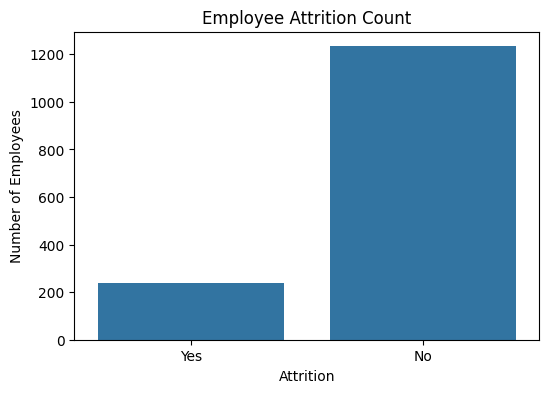

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x='attrition', data=df)
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()


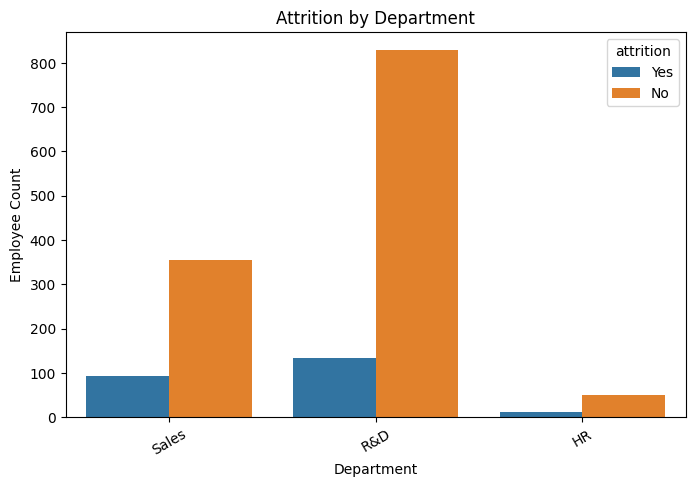

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(x='department', hue='attrition', data=df)
plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.xticks(rotation=30)
plt.show()


In [44]:
# safely find job role column
jobrole_col = None
for col in df.columns:
    if 'job' in col or 'role' in col or 'designation' in col:
        jobrole_col = col
        break

print("Job Role Column Found:", jobrole_col)


Job Role Column Found: job_role


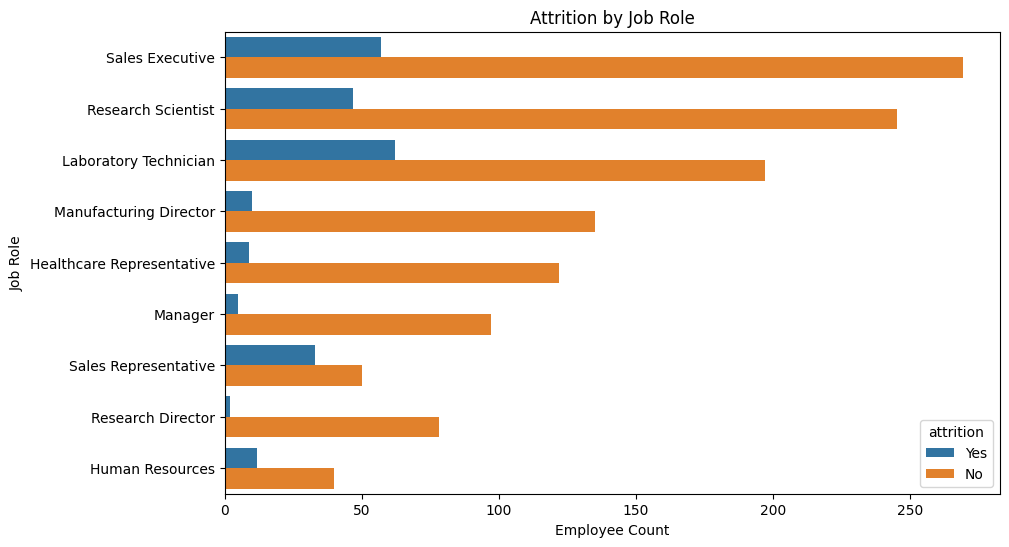

In [45]:
plt.figure(figsize=(10,6))
sns.countplot(y=jobrole_col, hue='attrition', data=df)
plt.title("Attrition by Job Role")
plt.xlabel("Employee Count")
plt.ylabel("Job Role")
plt.show()


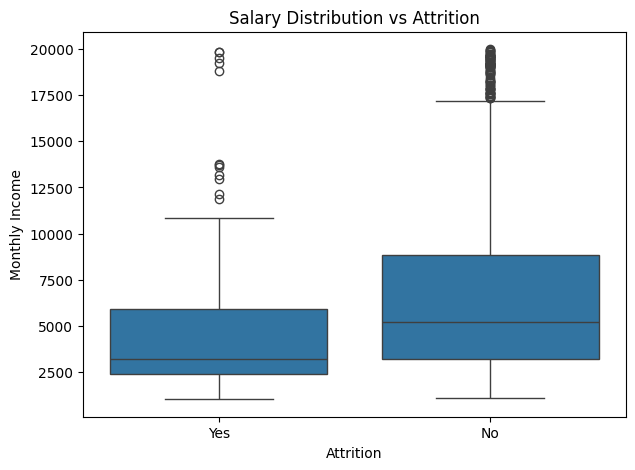

In [47]:
plt.figure(figsize=(7,5))
sns.boxplot(x='attrition', y=salary_col, data=df)
plt.title("Salary Distribution vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()


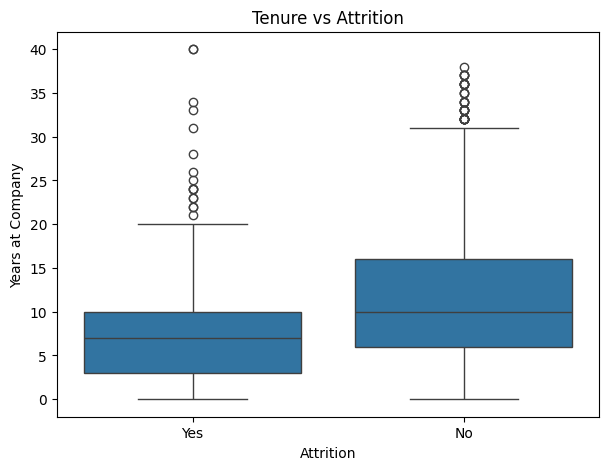

In [54]:
try:
    tenure_col = find_column(['years_at_company', 'tenure', 'years'], df.columns)
    df[tenure_col] = pd.to_numeric(df[tenure_col], errors='coerce')

    plt.figure(figsize=(7,5))
    sns.boxplot(x='attrition', y=tenure_col, data=df)
    plt.title("Tenure vs Attrition")
    plt.xlabel("Attrition")
    plt.ylabel("Years at Company")
    plt.show()



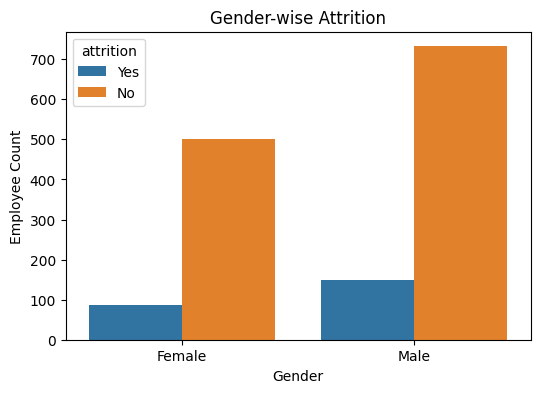

In [56]:
try:
    gender_col = find_column(['gender', 'sex'], df.columns)

    plt.figure(figsize=(6,4))
    sns.countplot(x=gender_col, hue='attrition', data=df)
    plt.title("Gender-wise Attrition")
    plt.xlabel("Gender")
    plt.ylabel("Employee Count")
    plt.show()

except KeyError as e:
    print("Step 3.6 skipped →", e)



In [59]:
pip install streamlit pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 68.5 MB/s eta 0:00:00


In [63]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="HR Analytics Dashboard", layout="wide")


df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "")
)



2025-12-25 09:21:31.675 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [72]:
df['attrition'] = df['attrition'].astype(str).str.strip().str.lower()
df['monthly_income'] = pd.to_numeric(df['monthly_income'], errors='coerce')
df['years_at_company'] = pd.to_numeric(df['years_at_company'], errors='coerce')

In [73]:
total_employees = df.shape[0]

attrition_count = df.loc[df['attrition'] == 'yes'].shape[0]
attrition_rate = round((attrition_count / total_employees) * 100, 2)

avg_salary = round(df['monthly_income'].mean(), 2)
avg_tenure = round(df['years_at_company'].mean(), 2)

In [74]:
print("Total Employees:", total_employees)
print("Attrition Count:", attrition_count)
print("Attrition Rate (%):", attrition_rate)
print("Average Salary:", avg_salary)
print("Average Tenure:", avg_tenure)


Total Employees: 1470
Attrition Count: 237
Attrition Rate (%): 16.12
Average Salary: 6502.93
Average Tenure: 7.01


In [75]:
kpi_df = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Attrition Count",
        "Attrition Rate (%)",
        "Average Salary",
        "Average Tenure (Years)"
    ],
    "Value": [
        total_employees,
        attrition_count,
        attrition_rate,
        avg_salary,
        avg_tenure
    ]
})

kpi_df


,Metric,Value
0,Total Employees,1470.00
1,Attrition Count,237.00
2,Attrition Rate (%),16.12
3,Average Salary,6502.93
4,Average Tenure (Years),7.01


In [76]:
st.subheader("Key HR Metrics")

c1, c2, c3, c4 = st.columns(4)

c1.metric("Total Employees", total_employees)
c2.metric("Attrition Rate (%)", attrition_rate)
c3.metric("Average Salary", avg_salary)
c4.metric("Avg Tenure (Years)", avg_tenure)


2025-12-25 09:30:34.650 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:30:34.934 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-12-25 09:30:34.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:30:34.942 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:30:34.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:30:34.949 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:30:34.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:30:34.957 Thread 'MainThread': mi

DeltaGenerator()

2025-12-25 09:32:55.056 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:32:55.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:32:55.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:32:55.276 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:32:55.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:32:55.580 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:32:55.585 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

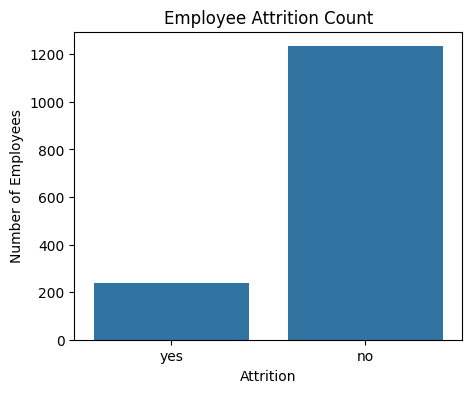

In [77]:
st.subheader(" Employee Attrition Overview")

fig, ax = plt.subplots(figsize=(5,4))

sns.countplot(
    x='attrition',
    data=df,
    ax=ax
)

ax.set_xlabel("Attrition")
ax.set_ylabel("Number of Employees")
ax.set_title("Employee Attrition Count")

st.pyplot(fig)


In [78]:
st.subheader("Attrition by Department")

fig, ax = plt.subplots(figsize=(7,4))

sns.countplot(
    x='department',
    hue='attrition',
    data=df,
    ax=ax
)

ax.set_xlabel("Department")
ax.set_ylabel("Employee Count")
ax.set_title("Attrition by Department")
plt.xticks(rotation=30)

st.pyplot(fig)


2025-12-25 09:33:54.275 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:33:54.276 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:33:54.278 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:33:54.345 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:33:54.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:33:54.535 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:33:54.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

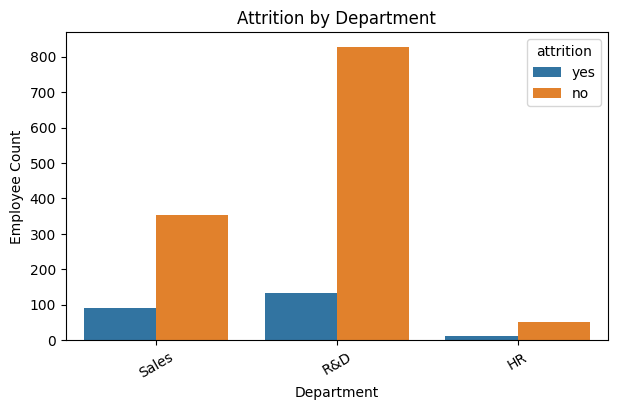

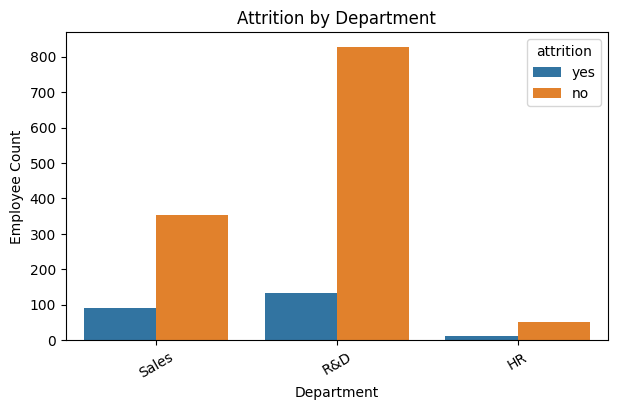

In [79]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='department',
    hue='attrition',
    data=df
)

plt.xlabel("Department")
plt.ylabel("Employee Count")
plt.title("Attrition by Department")
plt.xticks(rotation=30)

plt.show()


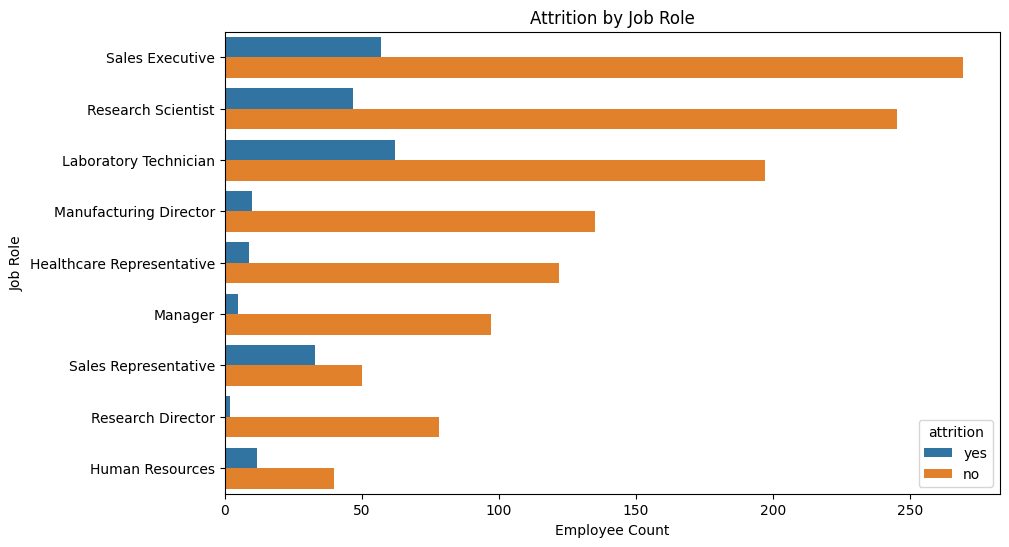

In [80]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='job_role',
    hue='attrition',
    data=df
)

plt.xlabel("Employee Count")
plt.ylabel("Job Role")
plt.title("Attrition by Job Role")

plt.show()


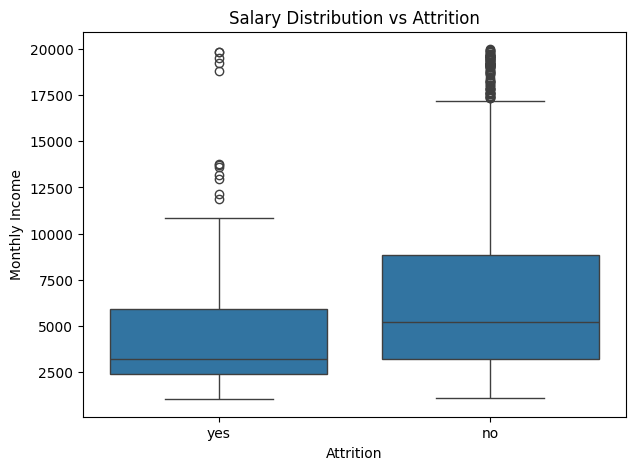

In [81]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='attrition',
    y='monthly_income',
    data=df
)

plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.title("Salary Distribution vs Attrition")

plt.show()


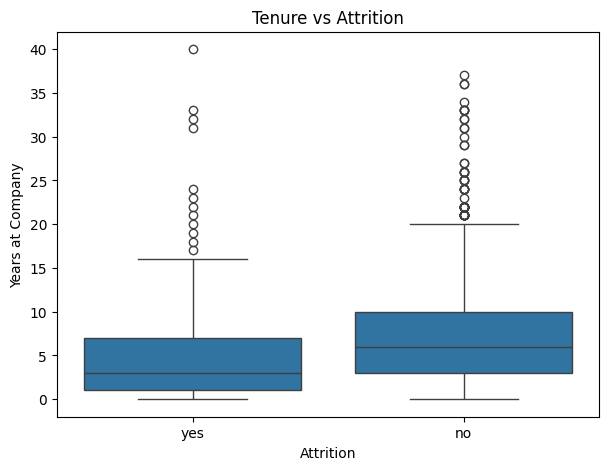

In [82]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='attrition',
    y='years_at_company',
    data=df
)

plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.title("Tenure vs Attrition")

plt.show()


In [83]:
dept_attrition_rate = (
    df.groupby('department')['attrition']
    .apply(lambda x: (x == 'Yes').sum() / x.count() * 100)
    .reset_index(name='attrition_rate_%')
)

dept_attrition_rate['attrition_rate_%'] = dept_attrition_rate['attrition_rate_%'].round(2)
dept_attrition_rate


,department,attrition_rate_%
0,HR,0.0
1,R&D,0.0
2,Sales,0.0


In [85]:
high_risk_df = df[
    (df['job_satisfaction'] <= 2) &
    (df['over_time'] == 'Yes') &
    (df['years_at_company'] <= 3)
]

high_risk_count = high_risk_df.shape[0]
high_risk_count


56

Which employees are likely to leave in the future?”

In [86]:
features = [
    'age',
    'job_satisfaction',
    'monthly_income',
    'years_at_company',
    'work_life_balance'
]

X = df[features]
y = df['attrition'].map({'yes': 1, 'no': 0})


In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [88]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [89]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.84

Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91       309
           1       0.00      0.00      0.00        59

    accuracy                           0.84       368
   macro avg       0.42      0.50      0.46       368
weighted avg       0.71      0.84      0.77       368



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


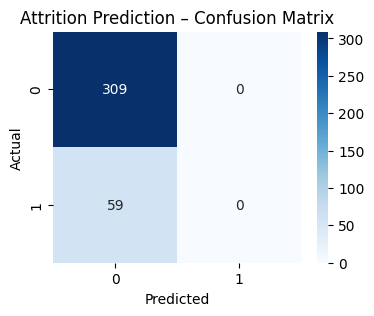

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Attrition Prediction – Confusion Matrix")
plt.show()


In [91]:
df['attrition_probability'] = model.predict_proba(X)[:, 1]

df[['employee_number', 'attrition_probability']].head()


,employee_number,attrition_probability
0,1,0.137458
1,2,0.083755
2,4,0.195311
3,5,0.146164
4,7,0.300165


In [92]:
top_risk_employees = (
    df[['employee_number', 'department', 'job_role', 'attrition_probability']]
    .sort_values(by='attrition_probability', ascending=False)
    .head(10)
)

top_risk_employees


,employee_number,department,job_role,attrition_probability
777,1079,R&D,Laboratory Technician,0.535020
1415,2023,Sales,Sales Representative,0.509253
1004,1839,R&D,Research Scientist,0.506876
1446,1494,R&D,Laboratory Technician,0.501069
871,1219,R&D,Laboratory Technician,0.491602
853,1193,R&D,Research Scientist,0.475910
734,1019,R&D,Laboratory Technician,0.467744
731,1016,R&D,Research Scientist,0.464304
1062,1735,R&D,Laboratory Technician,0.461854
1411,1504,R&D,Laboratory Technician,0.461847


In [97]:
total = len(df)
attrition_rate = round((df['attrition'] == 'yes').mean() * 100, 2)
avg_salary = round(df['monthly_income'].mean(), 2)
avg_tenure = round(df['years_at_company'].mean(), 2)

# ---------------- TITLE ----------------
st.title("📊 HR Analytics Dashboard")

# ---------------- KPI ROW ----------------
c1, c2, c3, c4 = st.columns(4)
c1.metric("Employees", total)
c2.metric("Attrition %", attrition_rate)
c3.metric("Avg Salary", avg_salary)
c4.metric("Avg Tenure", avg_tenure)

st.divider()

# ---------------- ROW 1 ----------------
col1, col2 = st.columns(2)

with col1:
    fig, ax = plt.subplots()
    sns.countplot(x='attrition', data=df, ax=ax)
    ax.set_title("Overall Attrition")
    st.pyplot(fig)

with col2:
    fig, ax = plt.subplots()
    sns.countplot(x='department', hue='attrition', data=df, ax=ax)
    ax.set_title("Attrition by Department")
    plt.xticks(rotation=30)
    st.pyplot(fig)

# ---------------- ROW 2 ----------------
col3, col4 = st.columns(2)

with col3:
    fig, ax = plt.subplots()
    sns.boxplot(x='attrition', y='monthly_income', data=df, ax=ax)
    ax.set_title("Salary vs Attrition")
    st.pyplot(fig)

with col4:
    corr = df[['age','monthly_income','years_at_company','job_satisfaction']].corr()
    fig, ax = plt.subplots()
    sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax)
    ax.set_title("Correlation Heatmap")
    st.pyplot(fig)











2025-12-25 09:48:10.128 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:48:10.130 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:48:10.130 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:48:10.132 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:48:10.133 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:48:10.134 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:48:10.136 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-25 09:48:10.136 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar